<a href="https://colab.research.google.com/github/faorjuelal/SIG---IIND---2026/blob/main/Notebooks/Taller_h2o_produccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Taller Práctico: Predicción de Entregas Tardías en E-Commerce con H2O AutoML
**Sistemas Avanzados de Producción — Universidad ECCI**

---

### Contexto del Negocio
Eres parte del equipo de **analítica de operaciones** de una empresa de e-commerce que gestiona cientos de miles de envíos mensuales. La gerencia de logística ha detectado que un porcentaje significativo de pedidos **no llega a tiempo**, generando insatisfacción, devoluciones y costos adicionales de servicio al cliente.

Tu misión: usar Machine Learning automatizado (H2O AutoML) para **predecir qué envíos llegarán tarde** antes de que salgan del almacén, y así tomar acciones preventivas (cambiar modo de transporte, priorizar picking en el almacén, o alertar proactivamente al cliente).

### Instrucciones
1. Ejecuta cada celda de código **en orden** (Shift + Enter).
2. Lee detenidamente los bloques de texto — contienen el marco teórico esencial para traducir métricas estadísticas a **decisiones de negocio**.
3. El entrenamiento de modelos tomará aproximadamente **10 minutos**. H2O evaluará múltiples algoritmos simultáneamente.
4. Al finalizar, responde las **preguntas gerenciales** de la sección final para tu informe.

---
## 🔧 PASO 1 — Instalación e Inicialización de H2O AutoML

H2O es una plataforma de Machine Learning distribuida y en memoria. Su módulo AutoML automatiza el ciclo completo: imputación de datos, codificación, entrenamiento de ensambles (Random Forest, Gradient Boosting, Deep Learning) y ajuste de hiperparámetros.

In [1]:
# Instalación de H2O
!pip install h2o -q

import h2o
from h2o.automl import H2OAutoML

# Inicializar el clúster local de H2O
h2o.init()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 5.4 MB/s eta 0:00:00
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmppeczjegb
  JVM stdout: /tmp/tmppeczjegb/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmppeczjegb/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 15 days
H2O_cluster_name:,H2O_from_python_unknownUser_23pin8
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


---
## 📥 PASO 2 — Generación y Carga de Datos a Gran Escala

Para simular un entorno empresarial real, generaremos un dataset con **150,000 envíos** y patrones lógicos (por ejemplo, los productos más pesados o con mayores descuentos tienen mayor probabilidad de retraso).

In [2]:
import pandas as pd
import numpy as np

print("⏳ Generando dataset a gran escala (150,000 registros)...")
np.random.seed(42)
n = 150000

data = pd.DataFrame({
    'warehouse_block': np.random.choice(['A','B','C','D','F'], n, p=[0.07,0.20,0.17,0.32,0.24]),
    'mode_of_shipment': np.random.choice(['Ship','Flight','Road'], n, p=[0.30,0.30,0.40]),
    'customer_care_calls': np.random.choice(range(1,8), n),
    'customer_rating': np.random.choice(range(1,6), n),
    'cost_of_the_product': np.random.randint(96, 310, n),
    'prior_purchases': np.random.choice(range(2,10), n),
    'product_importance': np.random.choice(['Low','Medium','High'], n, p=[0.33,0.34,0.33]),
    'gender': np.random.choice(['F','M'], n, p=[0.50,0.50]),
    'discount_offered': np.random.randint(0, 66, n),
    'weight_in_gms': np.random.randint(1000, 7067, n),
})

# Generar variable objetivo (1 = Tarde, 0 = A tiempo) con lógica de negocio
prob_late = 0.35 * np.ones(n)
prob_late += 0.15 * (data['discount_offered'] > 10).astype(float)
prob_late += 0.12 * (data['weight_in_gms'] > 4500).astype(float)
prob_late -= 0.10 * (data['cost_of_the_product'] > 250).astype(float)
prob_late += 0.08 * (data['customer_care_calls'] >= 5).astype(float)
prob_late -= 0.05 * (data['mode_of_shipment'] == 'Flight').astype(float)
prob_late += np.random.normal(0, 0.08, n)
prob_late = np.clip(prob_late, 0.05, 0.95)

# IMPORTANTE: En este taller, 1 = LLEGÓ TARDE (Es el evento que queremos detectar)
data['is_late'] = (np.random.random(n) < prob_late).astype(int)

print(f"📦 Total de envíos: {len(data):,} registros.")
print("\n📊 Distribución de la variable objetivo:")
print(data['is_late'].value_counts().rename({1: 'Tarde (1)', 0: 'A tiempo (0)'}))

# Convertir pandas DataFrame a H2OFrame
hf = h2o.H2OFrame(data)

# Indicar a H2O que es un problema de clasificación (variable categórica)
hf['is_late'] = hf['is_late'].asfactor()

# Convertir otras columnas categóricas a tipo factor para H2O
categorical_cols = ['warehouse_block', 'mode_of_shipment', 'product_importance', 'gender']
for col in categorical_cols:
    hf[col] = hf[col].asfactor()

# Dividir en Entrenamiento (80%) y Prueba (20%)
train, test = hf.split_frame(ratios=[0.8], seed=42)

⏳ Generando dataset a gran escala (150,000 registros)...
📦 Total de envíos: 150,000 registros.

📊 Distribución de la variable objetivo:
is_late
Tarde (1)       77769
A tiempo (0)    72231
Name: count, dtype: int64
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


---
## 📊 GUÍA DE MÉTRICAS — De la Estadística a la Estrategia de Negocio

Antes de entrenar los modelos, es vital entender cómo leeremos los resultados. En nuestro caso, la clase positiva (**1**) significa que el pedido **LLEGARÁ TARDE**.

### 1. AUC (Área bajo la curva ROC)
* **Definición Estadística:** Mide la capacidad del modelo para clasificar correctamente los positivos y negativos en diferentes umbrales. Va de 0.5 (azar) a 1.0 (perfecto).
* **Interpretación de Negocio:** *"Si tomamos un envío que realmente llegó tarde y uno que llegó a tiempo, ¿cuál es la probabilidad de que el modelo le asigne un riesgo mayor al que llegó tarde?"* Es la mejor métrica global para comparar modelos.

### 2. Recall (Sensibilidad)
* **Definición Estadística:** Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos).
* **Interpretación de Negocio (El enfoque del Servicio al Cliente):** *"De TODOS los pedidos que en la realidad van a llegar tarde, ¿cuántos logró detectar nuestra alarma?"*
* **Cuándo priorizarlo:** Si el costo de un cliente enojado (devolución del producto, mala reseña en redes) es altísimo. Queremos atrapar **todos** los retrasos posibles, aunque eso implique algunas falsas alarmas.

### 3. Precision (Precisión)
* **Definición Estadística:** Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos).
* **Interpretación de Negocio (El enfoque Financiero):** *"De todas las veces que la alarma sonó indicando '¡Llegará tarde!', ¿qué porcentaje era real?"*
* **Cuándo priorizarlo:** Si la acción preventiva es muy costosa. Por ejemplo, si para evitar un retraso pagamos un envío exprés en avión ($50 extra). Si la precisión es baja, estaremos gastando dinero en paquetes que de todos modos iban a llegar a tiempo (Falsas Alarmas).

### 4. F1-Score
* **Definición Estadística:** Media armónica entre Precision y Recall.
* **Interpretación de Negocio:** El punto de equilibrio. Se usa cuando queremos mitigar los retrasos, pero el presupuesto logístico es limitado y no podemos darnos el lujo de tener demasiados falsos positivos.

### 5. Logloss (Pérdida Logarítmica)
* **Definición Estadística:** Penaliza fuertemente las predicciones que están muy seguras de algo que es incorrecto.
* **Interpretación de Negocio:** Mide la "confianza" del modelo. Cuanto más cercano a 0, mejor. Un modelo con bajo logloss no solo acierta, sino que sus probabilidades de riesgo son altamente confiables.

---
## 🚀 PASO 3 — Entrenamiento Masivo con H2O AutoML

H2O entrenará y comparará familias enteras de algoritmos: Random Forests, Gradient Boosting Machines (XGBoost, LightGBM), Modelos Lineales Generalizados (GLM) y Redes Neuronales Profundas (Deep Learning).

⏱️ **Tiempo estimado: ~20 minutos. Deja la celda ejecutándose.**

In [3]:
# Configurar AutoML
# limitamos a 600 segundos (10 minutos) o un máximo de 20 modelos.
aml = H2OAutoML(
    max_models=20,
    max_runtime_secs=1200,
    seed=42,
    sort_metric="AUC" # Ordenar el tablero de posiciones por la métrica más robusta
)

# Ejecutar entrenamiento
print("Iniciando entrenamiento AutoML...")
aml.train(
    y='is_late',
    training_frame=train,
    validation_frame=test # Evaluamos en el conjunto de prueba directamente
)
print("¡Entrenamiento finalizado!")

Iniciando entrenamiento AutoML...
AutoML progress: |
23:32:25.537: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.

███████████████████████████████████████████████████████████████| (done) 100%
¡Entrenamiento finalizado!


---
## 🏆 PASO 4 — El Leaderboard (Tablero de Posiciones)

Veamos qué algoritmos obtuvieron el mejor rendimiento predictivo.

In [4]:
# Mostrar los mejores modelos
lb = aml.leaderboard
print("\n🏆 Top Modelos (Leaderboard):")
h2o.display.H2OTableDisplay(lb.head(20))


🏆 Top Modelos (Leaderboard):


model_id
GBM_5_AutoML_1_20260427_233225
GBM_2_AutoML_1_20260427_233225
XGBoost_3_AutoML_1_20260427_233225
GBM_3_AutoML_1_20260427_233225
GBM_1_AutoML_1_20260427_233225
GBM_4_AutoML_1_20260427_233225
DeepLearning_1_AutoML_1_20260427_233225
GLM_1_AutoML_1_20260427_233225
XGBoost_grid_1_AutoML_1_20260427_233225_model_2
XRT_1_AutoML_1_20260427_233225


---
## 🔍 PASO 5 — Diagnóstico del Modelo Ganador (The Leader)

Extraeremos el mejor modelo del AutoML para analizar cómo toma decisiones y dónde se equivoca.

In [5]:
mejor_modelo = aml.leader
print(f"🥇 El mejor modelo es: {mejor_modelo.algo.upper()}\n")

print("\n📊 MATRIZ DE CONFUSIÓN (En datos de prueba nuevos)")
print("Esto nos indica los Verdaderos Positivos, Falsos Positivos, etc.")
mejor_modelo.confusion_matrix(valid=True)

🥇 El mejor modelo es: GBM


📊 MATRIZ DE CONFUSIÓN (En datos de prueba nuevos)
Esto nos indica los Verdaderos Positivos, Falsos Positivos, etc.


,0,1,Error,Rate
0,845.0,13622.0,0.9416,(13622.0/14467.0)
1,366.0,15069.0,0.0237,(366.0/15435.0)
Total,1211.0,28691.0,0.4678,(13988.0/29902.0)



💡 IMPORTANCIA DE LAS VARIABLES (Feature Importance)
¿Cuáles son los factores logísticos que más influyen en un retraso?



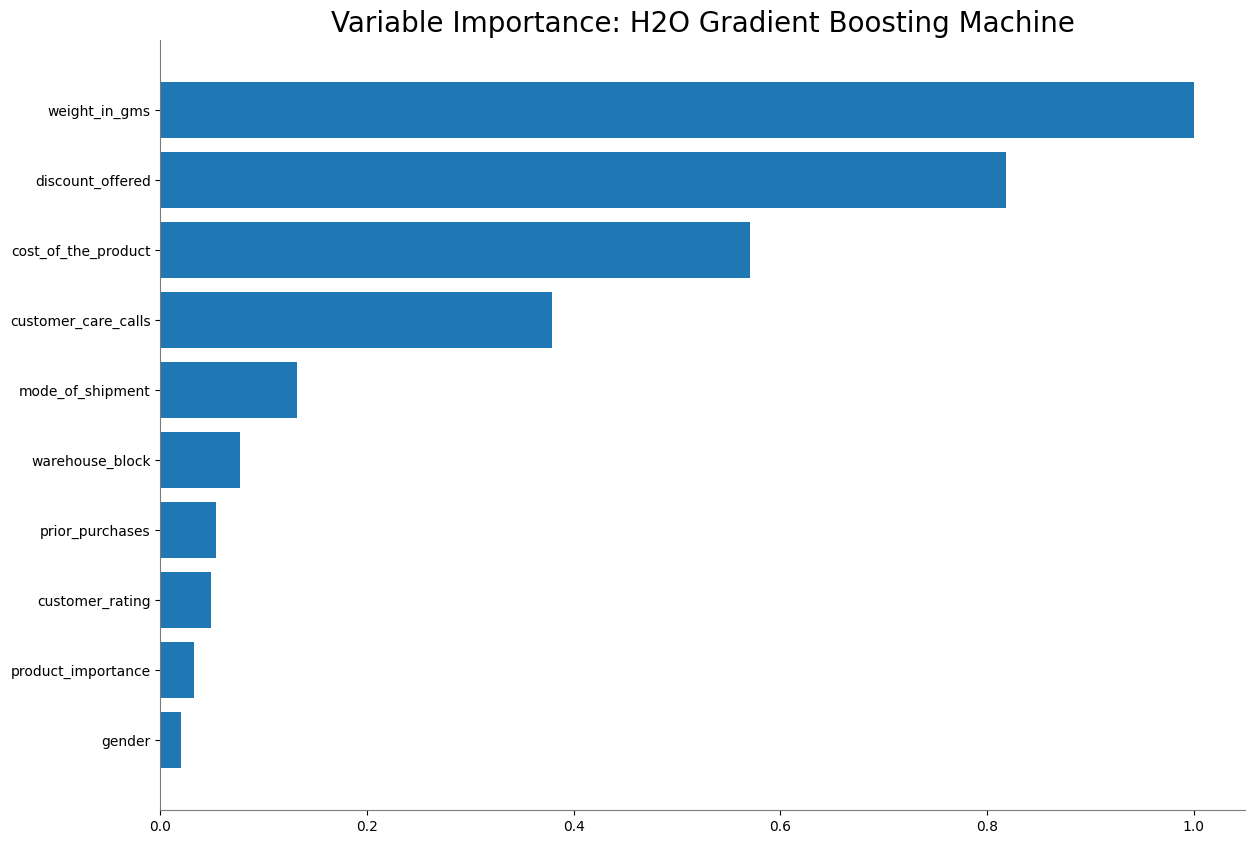

<Figure size 640x480 with 0 Axes>

In [6]:
print("\n💡 IMPORTANCIA DE LAS VARIABLES (Feature Importance)")
print("¿Cuáles son los factores logísticos que más influyen en un retraso?\n")
try:
    mejor_modelo.varimp_plot(num_of_features=10)
except:
    print("El modelo ganador es un Stacked Ensemble, que combina varios modelos y no tiene un gráfico directo de importancia simple. Revisa los modelos base para más detalle.")

---
## 🧠 PASO 6 — Inteligencia Artificial Explicable (XAI) para la Gerencia

A la gerencia de operaciones no le basta con saber *qué* paquete llegará tarde; necesita saber **POR QUÉ**. H2O AutoML incluye herramientas de explicabilidad que abren la "caja negra" del modelo, permitiéndonos ver exactamente qué variables empujan a que un pedido específico se retrase.

In [7]:
# CELDA 1: Tablero de Posiciones
print("🏆 1. Tablero de Posiciones (Leaderboard):")
# Extraemos el mejor modelo para usarlo en las siguientes celdas
mejor_modelo = aml.leader
h2o.display.H2OTableDisplay(aml.leaderboard.head(10))

🏆 1. Tablero de Posiciones (Leaderboard):


model_id
GBM_5_AutoML_1_20260427_233225
GBM_2_AutoML_1_20260427_233225
XGBoost_3_AutoML_1_20260427_233225
GBM_3_AutoML_1_20260427_233225
GBM_1_AutoML_1_20260427_233225
GBM_4_AutoML_1_20260427_233225
DeepLearning_1_AutoML_1_20260427_233225
GLM_1_AutoML_1_20260427_233225
XGBoost_grid_1_AutoML_1_20260427_233225_model_2
XRT_1_AutoML_1_20260427_233225


In [8]:
# CELDA 2: Matriz de Confusión
print("📊 2. Matriz de Confusión (En datos de prueba nuevos):")
print("Muestra los Verdaderos Positivos, Falsos Positivos, etc.")
rendimiento_test = mejor_modelo.model_performance(test)
rendimiento_test.confusion_matrix()

📊 2. Matriz de Confusión (En datos de prueba nuevos):
Muestra los Verdaderos Positivos, Falsos Positivos, etc.


,0,1,Error,Rate
0,845.0,13622.0,0.9416,(13622.0/14467.0)
1,366.0,15069.0,0.0237,(366.0/15435.0)
Total,1211.0,28691.0,0.4678,(13988.0/29902.0)


🔥 3. Mapa de Calor de Importancia de Variables:

🔗 4. Mapa de Correlación de Modelos:


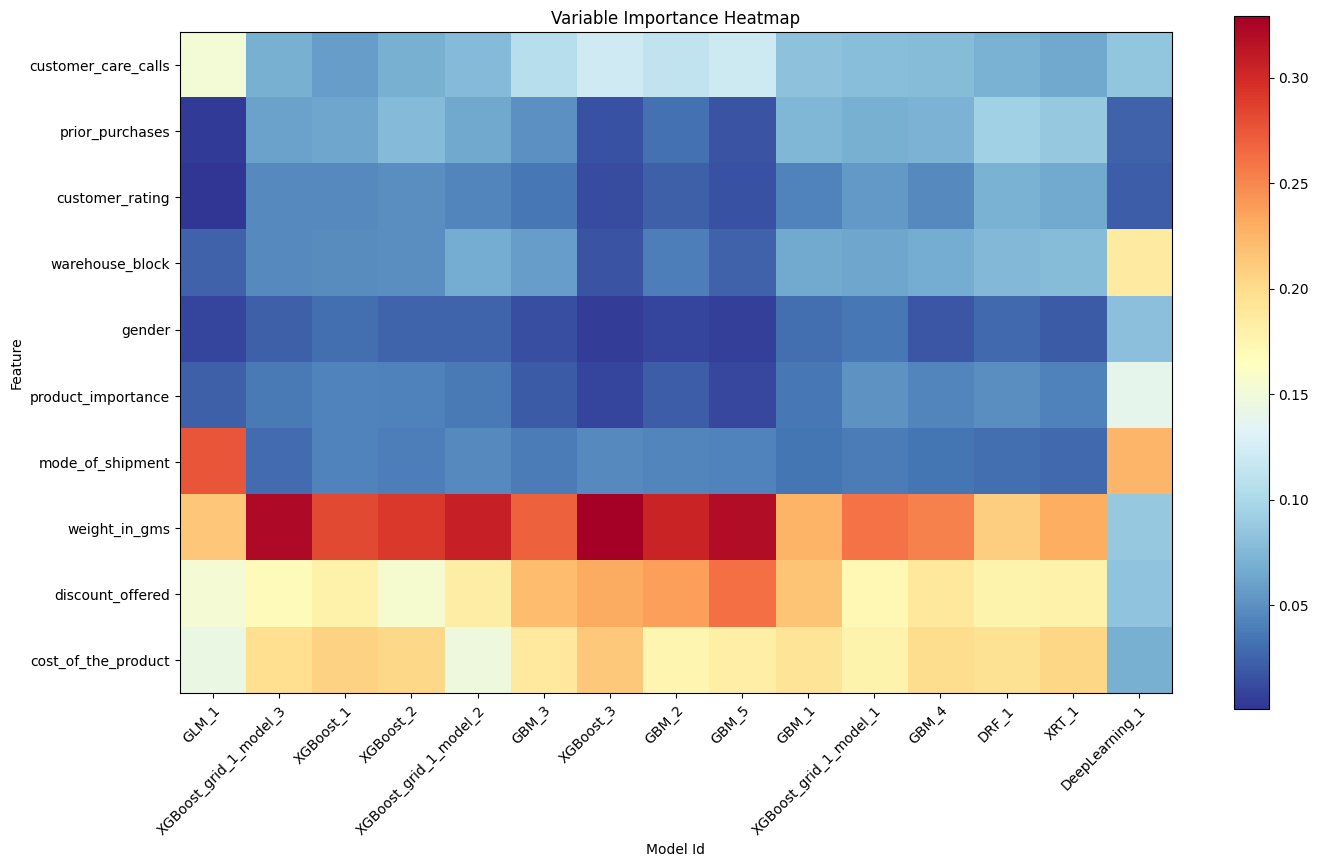

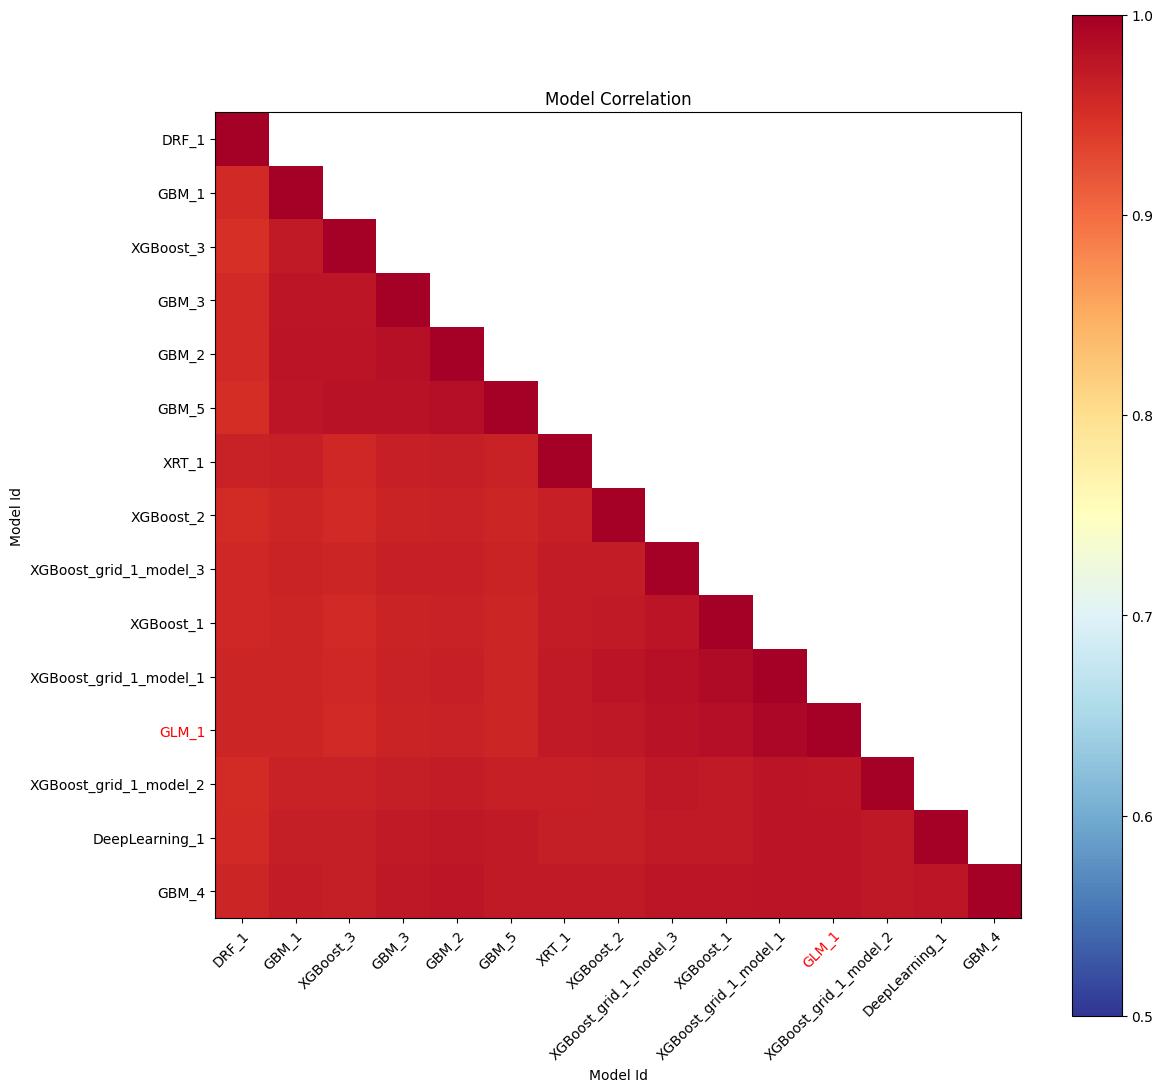

In [9]:
# CELDA 3: Mapas de Calor Gerenciales
print("🔥 3. Mapa de Calor de Importancia de Variables:")
try:
    aml.varimp_heatmap()
except:
    pass

print("\n🔗 4. Mapa de Correlación de Modelos:")
try:
    aml.model_correlation_heatmap(test)
except:
    pass

📈 5. Curva de Aprendizaje del Mejor Modelo:

🚨 6. Predicción en tiempo real para el Envío #5:
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
  predict        p0        p1
        1  0.437858  0.562142
[1 row x 3 columns]



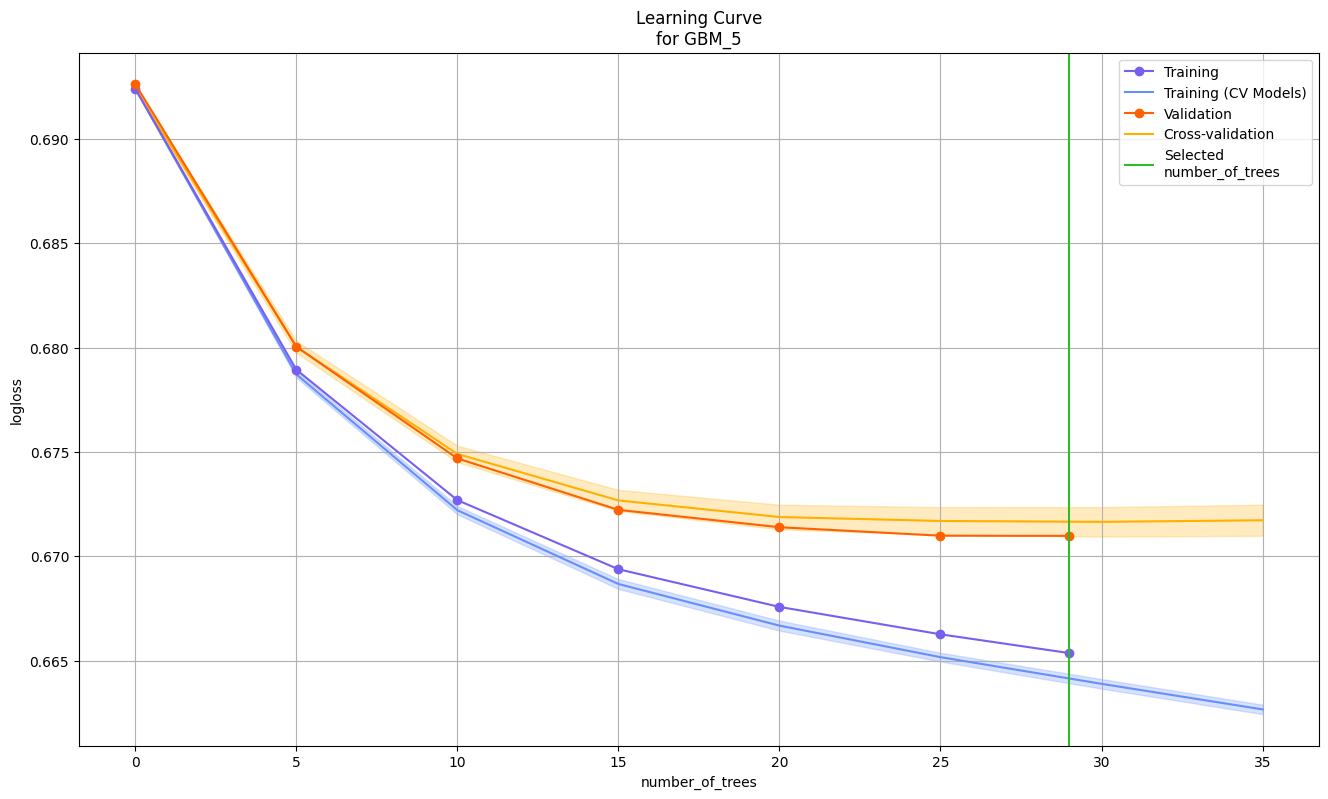

In [10]:
# CELDA 4: Curva de Aprendizaje y Caso Individual
print("📈 5. Curva de Aprendizaje del Mejor Modelo:")
try:
    mejor_modelo.learning_curve_plot()
except Exception as e:
    print("Gráfico de curva de aprendizaje no disponible para esta arquitectura.")

print("\n🚨 6. Predicción en tiempo real para el Envío #5:")
prediccion_individual = mejor_modelo.predict(test[5, :])
print(prediccion_individual)

---
## 📈 PASO 7 — Exportación de Datos para Dashboards (Power BI / Looker)

En un entorno real de **Sistemas de Información Gerencial**, los directivos no leen código en Python. Las predicciones del modelo deben integrarse en un Dashboard Ejecutivo interactivo.

A continuación, cruzaremos las predicciones del modelo con los datos originales y exportaremos los archivos CSV listos para ser conectados a Power BI o Looker Studio.

In [11]:
from google.colab import files

print("⚙️ INICIANDO EXTRACCIÓN DE DATOS PARA LOOKER STUDIO...")

# 1. Generar predicciones y unirlas con los datos originales del set de prueba
mejor_modelo = aml.leader
predicciones_h2o = mejor_modelo.predict(test)
datos_completos_h2o = test.cbind(predicciones_h2o)

# 2. Convertir a Pandas DataFrame para exportar
df_gerencial = datos_completos_h2o.as_data_frame()

# 3. Renombrar columnas para que sean KPIs legibles en Looker Studio
# Ajustado al contexto de Ingeniería Industrial (Mantenimiento de Máquinas)
df_gerencial.rename(columns={
    'predict': 'Alerta_Falla_Maquina',
    'p0': 'Prob_Operacion_Normal',
    'p1': 'Prob_Falla_Catastrofica'
}, inplace=True)

# 4. Exportar Dataset de Predicciones a CSV
archivo_predicciones = "1_KPIs_Mantenimiento_Looker.csv"
df_gerencial.to_csv(archivo_predicciones, index=False)
print(f"✅ Archivo principal generado: {archivo_predicciones}")

# 5. Exportar Importancia de Variables (para gráficos de Pareto de Causa Raíz)
try:
    df_importancia = mejor_modelo.varimp(use_pandas=True)
    archivo_importancia = "2_Causas_Raiz_Fallas.csv"
    df_importancia.to_csv(archivo_importancia, index=False)
    print(f"✅ Archivo de causas raíz generado: {archivo_importancia}")
except:
    print("⚠️ El modelo es un Stacked Ensemble. Se omitirá el archivo de causas raíz simple.")

# 6. Descargar automáticamente los archivos a tu computador
print("\n📥 Descargando archivos a tu computadora...")
files.download(archivo_predicciones)
try:
    files.download(archivo_importancia)
except:
    pass

print("\n🚀 LISTO. Instrucciones para tus estudiantes en Looker Studio:")
print("1. Suban el archivo CSV descargado a Google Drive y ábranlo como 'Google Sheets' (es la mejor forma de integrarlo).")
print("2. Vayan a Looker Studio -> Crear -> Informe.")
print("3. Elijan el conector 'Hojas de cálculo de Google', seleccionen su archivo ¡y comiencen a diseñar el Dashboard!")

⚙️ INICIANDO EXTRACCIÓN DE DATOS PARA LOOKER STUDIO...
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


✅ Archivo principal generado: 1_KPIs_Mantenimiento_Looker.csv
✅ Archivo de causas raíz generado: 2_Causas_Raiz_Fallas.csv

📥 Descargando archivos a tu computadora...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🚀 LISTO. Instrucciones para tus estudiantes en Looker Studio:
1. Suban el archivo CSV descargado a Google Drive y ábranlo como 'Google Sheets' (es la mejor forma de integrarlo).
2. Vayan a Looker Studio -> Crear -> Informe.
3. Elijan el conector 'Hojas de cálculo de Google', seleccionen su archivo ¡y comiencen a diseñar el Dashboard!


---
## ✍️ MINI-TALLER GERENCIAL: Toma de Decisiones Basada en Datos (Data-Driven Decision Making)

**Instrucciones para el entregable:**
Imagina que eres el **Ingeniero de Confiabilidad y Sistemas** de la planta. Debes redactar un memorando ejecutivo (máximo 2 páginas) dirigido al Director de Operaciones respondiendo a las siguientes cuestiones. Basa todas tus respuestas estrictamente en los datos del `Leaderboard`, la `Matriz de Confusión` y tu dashboard de `Looker Studio`.

### Bloque 1: Elección Tecnológica (Sistemas de Información)
**P1. Análisis de Arquitecturas:** Revisa el tablero de posiciones (Leaderboard) de H2O. ¿Qué familia de algoritmos (ej. XGBoost, Random Forest, Stacked Ensembles, GLM) ocupó el primer lugar? Desde la perspectiva de la física del mecanizado, ¿por qué crees que los modelos de "Árboles de Decisión" superan a los modelos lineales al predecir averías basadas en sensores de temperatura y torque?

### Bloque 2: Análisis de Riesgo y Costos (Matriz de Confusión)
Observa la Matriz de Confusión generada sobre los datos de prueba. En nuestra planta:

* Una inspección preventiva toma 30 minutos y cuesta **$150 USD** en tiempo de inactividad.

* Una falla catastrófica no detectada daña la herramienta y detiene la línea por 8 horas, costando **$5,000 USD**.

**P2. Falsos Positivos (El costo de la paranoia):** ¿Cuántas veces el modelo generó una alerta falsa (predijo falla, pero la máquina estaba sana)? ¿Cuánto dinero "desperdició" el modelo en inspecciones innecesarias durante esta prueba?

**P3. Falsos Negativos (El costo de la ceguera):** ¿Cuántas máquinas fallaron sin que el modelo avisara? ¿Cuál fue el costo financiero de estos fallos catastróficos?

**P4. Veredicto de ROI:** Sumando ambos costos, ¿es financieramente rentable implementar este modelo frente a no tener nada y dejar que las máquinas se rompan al azar? Muestra tu cálculo rápido.

### Bloque 3: Estrategia Operativa y KPIs
**P5. Tensión de Métricas (Recall vs. Precision):** El Jefe de Producción te exige que la máquina no se detenga por inspecciones falsas (quiere **Precision** alta). El Jefe de Seguridad Ocupacional exige que ninguna máquina estalle en pleno funcionamiento (quiere **Recall** alto). Si el riesgo de avería implica un peligro físico real para el operario, ¿qué métrica configuras para que el algoritmo priorice? Justifica tu respuesta.

### Bloque 4: Causa Raíz y Acción Correctiva (Looker Studio / XAI)
**P6. Intervención en el Piso de Planta:** Basado en el Dashboard de Looker Studio (o el archivo de Causas Raíz), ¿cuáles son los 2 parámetros físicos que más detonan las averías (ej. Velocidad de rotación, Desgaste de herramienta, Torque)?

**P7. Política Gerencial:** Redacta una nueva "Regla de Operación" de 2 líneas para los operarios de turno de mañana basándote en el hallazgo anterior (ej. *"A partir de hoy, si el sensor X supera el valor Y..."*).

---
© 2026 — Universidad ECCI · Sistemas de Información Gerencial.

# 📊 GUÍA PRÁCTICA: Creación de Dashboard Ejecutivo en Looker Studio

Una vez que la Inteligencia Artificial ha procesado los datos, el rol del Ingeniero es transformar esas métricas en una herramienta de decisión para la gerencia. En esta sección, aprenderás a conectar los resultados de H2O AutoML con **Looker Studio (Google)**.

---

### 🛠️ PASO 1: Preparación de la Fuente de Datos
Looker Studio funciona de manera óptima y fluida cuando los datos están en el ecosistema de Google.
1.  Busca en tu computadora los archivos CSV descargados (`1_KPIs_Mantenimiento_Looker.csv` y `2_Causas_Raiz_Fallas.csv`).
2.  Sube ambos archivos a una carpeta en tu **Google Drive**.
3.  Haz clic derecho sobre cada archivo y selecciona **"Abrir con" -> "Hojas de cálculo de Google"**.
    * *Nota: Esto convertirá el CSV estático en una hoja dinámica que Looker puede leer fácilmente.*

---

### 🔗 PASO 2: Conexión con Looker Studio
1.  Ingresa a [Looker Studio](https://lookerstudio.google.com/).
2.  Haz clic en el botón **Crear** (arriba a la izquierda) y selecciona **Informe**.
3.  En la ventana "Añadir datos al informe", selecciona el conector **Hojas de cálculo de Google**.
4.  Busca y selecciona el archivo `1_KPIs_Mantenimiento_Looker`. Haz clic en **Añadir**.
5.  Repite el proceso para añadir la segunda fuente de datos: `2_Causas_Raiz_Fallas`.

---

### 🎨 PASO 3: Diseño del Dashboard Ejecutivo
Diseña los siguientes cuatro componentes esenciales para una gerencia de planta:

#### **A. Indicadores de Nivel (Scorecards)**
* **Qué hacer:** Ve a "Añadir un gráfico" -> **Cuadro de resultados**.
* **KPI 1:** Usa la métrica `Record Count` para mostrar el total de máquinas monitoreadas.
* **KPI 2:** Crea un campo calculado o usa el promedio de `Prob_Falla_Catastrofica` para mostrar el **Índice de Riesgo Promedio**.

#### **B. Análisis de Causa Raíz (Pareto de IA)**
* **Qué hacer:** Ve a "Añadir un gráfico" -> **Gráfico de barras**.
* **Fuente de datos:** Cambia la fuente al archivo `2_Causas_Raiz_Fallas`.
* **Configuración:** * Dimensión: `variable`.
    * Métrica: `percentage` o `scaled_importance`.
* **Interpretación:** Este gráfico le dice al gerente qué sensor es el responsable principal de las alertas.

#### **C. Matriz de Priorización (Action List)**
* **Qué hacer:** Ve a "Añadir un gráfico" -> **Tabla**.
* **Configuración:** Añade las columnas `warehouse_block` (warehouse_block), `product_importance`, `weight_in_gms` y la `Prob_Falla_Catastrofica`.
* **Estilo:** En la pestaña "Estilo" de la tabla, selecciona la columna de probabilidad y activa **"Formato condicional"**. Pon en **Rojo** los valores superiores a 0.70.
* **Objetivo:** Esta es la lista que el mecánico usará para saber qué máquina revisar primero.

#### **D. Controles Interactivos (Filtros)**
* **Qué hacer:** Ve a "Añadir un control" -> **Lista desplegable**.
* **Campo:** Usa el campo `product_importance` (Calidad/Tipo de máquina: L, M, H).
* **Función:** Esto permite al gerente filtrar y ver solo las máquinas de "Alta Calidad" o "Baja Calidad".

---
